In [11]:
import torch
import torchvision
import torch.nn as nn

import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Автокодировщик

основная модель MNIST-MNIST

Модель шумоподавления:
    
    - вход : изображения 28х28 с гаусовым шумом (параметр уровня зашумления noise)
    - выход : изображение 28х28 идеальное
    
    - потери : MSE
    - метрика : PSNR (https://en.wikipedia.org/wiki/Peak_signal-to-noise_ratio)

## задание 1
    1.1 реализовать метрику PSNR
    1.2 проверить на примерах ее качество : сравнить изображение с разной степенью зашумления с идеальным имсходным изображением


In [234]:
from torch import Tensor, tensor

def psnr_compute(target: Tensor, y: Tensor, num_obs: Tensor, data_range: Tensor, base: float = 10.0,  image_size=28) -> Tensor:
    """peak signal-to-noise ratio.

    Args:
        sum_squared_error: суммарная квадратичная ощибка наблюдений
        num_obs: число объектов
        data_range: диапазон сигнала.
        base: основание логарифма
        reduction: метод ["elementwise_mean", "sum", "none", None]

            - ``'elementwise_mean'``: среднее(default)
            - ``'sum'``: сумма
            - ``'none'`` or ``None``: без объединения

    """
    sum_squared_error = torch.sum((target - y)**2).cpu()
    
    psnr_base_e = 2 * torch.log(data_range) - torch.log(sum_squared_error / num_obs / (image_size**2))
    psnr_vals = psnr_base_e * (10 / torch.log(tensor(base)))
    return torch.mean(psnr_vals)

## задание 2
    2.1 собрать модель автоэнкодера с изменяемой шириной и глубиной энкодера и декодера
    2.2 проверить сборку на тестовом примере: тензор на входе соответсвует целевому размеру входного изображения, оцениваем тензор на выходе

In [223]:
def blocc( h1, h2, hiden_size, kernel):
    return nn.Sequential(nn.Conv2d(h1, hiden_size, kernel, padding=1), 
                         nn.BatchNorm2d(hiden_size), nn.ReLU(), 
                         nn.Conv2d(hiden_size, h2, kernel, padding=1), 
                         nn.BatchNorm2d(h2), nn.ReLU())       

class Encoder(nn.Module):
        
    def __init__(self, hiden_size, im_size):
        super(Encoder, self).__init__()
        self.im_size = im_size
        self.hiden_size = hiden_size
        # print(self.im_size)
        self.c1 = blocc(self.im_size[0], hiden_size * 2, hiden_size, 3)
        self.p1 = nn.MaxPool2d(2,2)
        self.c2 = blocc(hiden_size * 2, hiden_size * 4, hiden_size * 4, 3)
        self.p2 = nn.MaxPool2d(2,2)
        self.c3 = blocc(hiden_size * 4, hiden_size * 8, hiden_size * 8, 3)
        self.p3 = nn.MaxPool2d(2,2)
        self.latent = nn.Linear((im_size[1] // 8) * (im_size[2] // 8) * hiden_size * 8, hiden_size * 8 )
        
    def forward(self, input_):
        # print('input ',input_)
        x = self.c1(input_)
        x = self.p1(x)
        # print('e:b1 ',x.shape)
        x = self.c2(x)
        x = self.p2(x)
        #print('e:b2 ',x.shape)
        x = self.c3(x)
        x = self.p3(x)
        #print('e:b3 ',x.reshape(input.shape[0], -1,).shape, (self.im_size[0] // 8) * (self.im_size[1] // 8) * self.hiden_size * 8, self.hiden_size * 8 )
        x = self.latent(x.reshape(input_.shape[0], -1,))
        #print('e:l ',x.shape)
        return x

class Decoder(nn.Module):
    
        
    def __init__(self, hiden_size, im_size):
        super(Decoder, self).__init__()
        self.im_size = im_size
        self.hiden_size = hiden_size
        #print(self.irm_size)
        self.latent = nn.Linear(hiden_size * 8, (im_size[2] // 8) * (im_size[1] // 8) * hiden_size * 8, )
        # im_size[1] // 8, im_size[1] // 8,  hiden_size * 8
        self.c3 = blocc(hiden_size * 8, hiden_size * 4, hiden_size * 8, 3)
        self.p3 = nn.ConvTranspose2d( hiden_size * 4, hiden_size * 4, kernel_size=3, stride=2, padding=0)# (in_channels: int, out_channels: int, kernel_size: Union[int, Tuple[int, int]], stride
        
        self.c2 = blocc(hiden_size * 4, hiden_size * 2, hiden_size * 4, 3)
        self.p2 = nn.ConvTranspose2d( hiden_size * 2, hiden_size * 2, kernel_size=3, stride=2, padding=0)# (in_channels: int, out_channels: int, kernel_size: Union[int, Tuple[int, int]], stride
        
        self.c1 = blocc(hiden_size * 2, hiden_size * 2, hiden_size * 2, 3)
        self.p1 = nn.ConvTranspose2d( hiden_size * 2, hiden_size, kernel_size=2, stride=2, padding=0)# (in_channels: int, out_channels: int, kernel_size: Union[int, Tuple[int, int]], stride

        self.c01 = nn.Conv2d(hiden_size, hiden_size, 3, padding=0)
        self.c02 = nn.Conv2d(hiden_size, self.im_size[0], 3, padding=1)
        self.out = nn.Sigmoid()
        
    def forward(self, input_):
        # print(input.shape)
        x = self.latent(input_)
        x = x.reshape(input_.shape[0], self.hiden_size * 8,self.im_size[1]//8,self.im_size[2]//8)
        # print('latent ',x.shape)
        x = self.c3(x)
        x = self.p3(x)
        # print('d:b3 ',x.shape)
        
        x = self.c2(x)
        x = self.p2(x)
        # print('d:b2 ',x.shape)
        
        x = self.c1(x)
        x = self.p1(x)
        # print('d:b1 ',x.shape)

        x = self.c01(x)
        x = self.c02(x)
        # print('d:out ',x.shape)
        
        return self.out(x)
        
class Autoencoder_Base(nn.Module):
    def __init__(self, hiden_size, im_size):
        super(Autoencoder_Base, self).__init__()
        self.encoder = Encoder(hiden_size, im_size)
        self.decoder = Decoder(hiden_size, im_size)
    def forward(self, input_):
        #print(input.shape)0
        return self.decoder(self.encoder(input_))
        
    

Проверка

In [207]:
AE = Autoencoder_Base(8,[1,28,28])

In [208]:
X = torch.tensor(np.ones([1,1,28,28]), dtype=torch.float32)*1.0
X.shape


torch.Size([1, 1, 28, 28])

In [209]:
out = AE(X)
out.shape

torch.Size([1, 1, 28, 28])

## задание 3
    3.1 Загрузить данные MNIST (рукописные цифры)
    3.2 Создать датасет с зашумлением данных по заданной форме: гаусовый шум, шум "соль/перец", регуляррные полосы
    3.3 проверить на примерах ее качество формировния входа (оценить PSNR - сравнить изображение с разной степенью зашумления с идеальным имсходным изображением)

Читаем MNIST

In [213]:
ds = torchvision.datasets.MNIST(root='./', train=True, download=True) 
ds_test = torchvision.datasets.MNIST(root='./', train=False, download=True) 

In [ ]:

class NoiceDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, noise=0.1, noise_type='gaussian'):
        """
        Args:
            dataset: исходный датасет
            noise: уровень зашумления
            noise_type: тип шума ('gaussian', 'salt_pepper', 'stripes')
        """
        self._data = dataset
        self._length = len(dataset)
        self.size = [1, 28,28]
        self.noise = noise
        self.noise_type = noise_type

    def __len__(self):
        return len(self._data)

    def encode_image(self, im):
        im_array = np.array(im)
        
        if self.noise_type == 'gaussian':
            # Гаусов шум
            encoded = (np.random.randn(self.size[0],self.size[1],self.size[2],) * self.noise * 255).astype(np.int32) + im_array
            encoded = np.clip(encoded, 0., 255.).astype(np.uint8)
            
        elif self.noise_type == 'salt_pepper':
            # Шум "соль/перец"
            encoded = im_array.copy()
            noise_mask = np.random.random((self.size[1], self.size[2])) < self.noise
            # Соль (белые пиксели)
            salt_mask = noise_mask & (np.random.random((self.size[1], self.size[2])) < 0.5)
            # Перец (черные пиксели)
            pepper_mask = noise_mask & ~salt_mask
            encoded[0][salt_mask] = 255
            encoded[0][pepper_mask] = 0
            encoded = encoded.astype(np.uint8)
            
        elif self.noise_type == 'stripes':
            # Регулярные полосы
            encoded = im_array.copy().astype(np.float32)
            stripe_width = max(1, int(28 * self.noise))
            for i in range(0, 28, stripe_width * 2):
                if i + stripe_width < 28:
                    encoded[0][i:i+stripe_width, :] = 255 * self.noise
            encoded = np.clip(encoded, 0., 255.).astype(np.uint8)
        else:
            encoded = im_array.astype(np.uint8)
            
        return encoded

    def __getitem__(self, index):
        im, _ = self._data[index]
        return torch.from_numpy(self.encode_image(im).astype(np.float32)/255.), torch.from_numpy(np.array(im).astype(np.float32)[None]/255.)

In [ ]:
train_dataset = NoiceDataset(ds, noise=0.2)
valid_dataset = NoiceDataset(ds_test, noise=0.2)
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=128, shuffle=True, num_workers=3
)
valid_loader = torch.utils.data.DataLoader(
    valid_dataset, batch_size=128, shuffle=False, num_workers=1
)


torch.Size([1, 28, 28]) torch.Size([1, 28, 28])


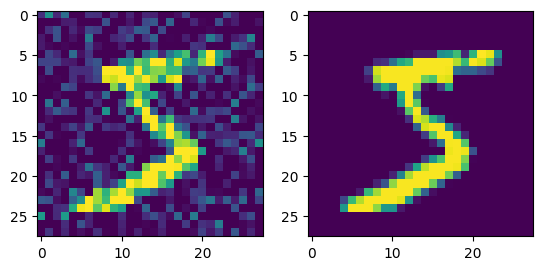

In [ ]:
import matplotlib.pyplot as plt

im_in, im_out =  train_dataset[0]
print(im_in.shape, im_out.shape,)

plt.subplot(1,2,1)
plt.imshow(im_in.numpy()[0,:,:])
plt.title('Зашумленное изображение')
plt.subplot(1,2,2)
plt.imshow(im_out.numpy()[0, :,:])
plt.title('Исходное изображение')
plt.show()

# Проверка PSNR для задания 1.2
print("\nПроверка PSNR для разных уровней зашумления:")
for noise_level in [0.1, 0.2, 0.5, 0.8]:
    test_dataset = NoiceDataset(ds_test, noise=noise_level)
    test_im_in, test_im_out = test_dataset[0]
    psnr_val = psnr_compute(test_im_out[None], test_im_in[None], 
                           torch.tensor([1.]), torch.tensor([1.]), base=10.0)
    print(f"Noise={noise_level}: PSNR={psnr_val.item():.2f} dB")

## задание 4
    4.1 записать цикл обучения модели
    4.2 провести обучение
    4.3 оценить и визуализировать результаты

In [227]:
def train_epoch(model, dataloader, loss_fn, optimizer, device):
    model.train()
    total_loss = 0
    
    for batch_idx, (images, masks) in enumerate(dataloader):
        images = images.to(device)
        masks = masks.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        # print(outputs.shape, masks.shape)
        loss = loss_fn(outputs, masks)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        print(end=".")
        # 
    
    return total_loss / len(dataloader)

def validate_epoch(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0
    metrics = 0
    with torch.no_grad():
        for batch_idx, (images, masks) in enumerate(dataloader):
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            # print(outputs.shape, masks.shape)
            loss = loss_fn(outputs, masks)
            total_loss += loss.item()
            metric = psnr_compute(masks, outputs, outputs.shape[0], torch.Tensor([1.]), base = 10.)
            metrics += metric.item()

    
    return total_loss / len(dataloader), metrics / len(dataloader)

In [228]:
def train_model(model, train_loader, val_loader, loss_fn, optimizer, scheduler, 
                epochs, device, save_path='best_model.pth'):
    """
    Complete training cycle
    """
    best_val_loss = float('inf')
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        print(f'Epoch {epoch+1}/{epochs}')
        print('-' * 50)
        
        # Training phase
        train_loss = train_epoch(model, train_loader, loss_fn, optimizer, device)
        train_losses.append(train_loss)
        
        # Validation phase
        val_loss, metric = validate_epoch(model, val_loader, loss_fn, device)
        val_losses.append(val_loss)
        
        # Learning rate scheduling
        scheduler.step(val_loss)
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': val_loss,
            }, save_path)
            print(f'Best model saved with val_loss: {val_loss:.4f}')
        
        print(f'Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Metric: {metric:.4f}')
        print(f'Current LR: {optimizer.param_groups[0]["lr"]:.2e}')
        print()
    
    return train_losses, val_losses, model

In [235]:
loss_fn = nn.MSELoss()
device = "cuda" if torch.cuda.is_available() else "cpu"
AE = AE.to(device)
# Optimizer, scheduler
optimizer = torch.optim.Adam([
    {'params': AE.decoder.parameters(), 'lr': 1e-4},
    {'params': AE.encoder.parameters(), 'lr': 1e-5},
])

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.1)

train_losses, val_losses, AE_train = train_model(
        model=AE,
        train_loader=train_loader,  # 
        val_loader=valid_loader,      # 
        loss_fn=loss_fn,
        optimizer=optimizer,
        scheduler=scheduler,
        epochs=5,
        device=device,
        save_path='best_segmentation_model.pth'
    )

Epoch 1/5
--------------------------------------------------
.....................................................................................................................................................................................................................................................................................................................................................................................................................................................................................Best model saved with val_loss: 0.0092
Train Loss: 0.0096, Val Loss: 0.0092, Metric: 20.3979
Current LR: 1.00e-04

Epoch 2/5
--------------------------------------------------
......................................................................................................................................................................................................................................................................................................

Собираем модель


Собираем модель


torch.Size([1, 28, 28]) torch.Size([1, 28, 28])


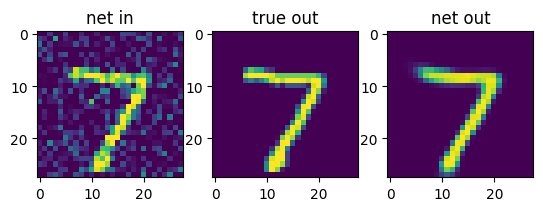

In [171]:
n = 0
im_in, im_out =  valid_dataset[n]
print(im_in.shape, im_out.shape,)

AE = AE.to("cuda")
y = AE(im_in.to("cuda")[None])

plt.subplot(1,3,3)
plt.imshow(y.detach().cpu().numpy()[0, 0, :,:])
plt.title('net out')
plt.subplot(1,3,1)
plt.imshow(im_in[0, :,:])
plt.title('net in')
plt.subplot(1,3,2)
plt.imshow(im_out[0,  :,:])
plt.title('true out')
plt.show()

## задание 5
    5.1 провести обучение моделей для разных значений noise^ 0.1, 0.2, 0.5, 0.8 
    5.2 оценить и визуализировать результаты
    5.3 Загрузить набор данных fashionMNIST (test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform))
    5.4 Провести подготовку данных с зашумлением (гаусов шум 0.1) и проверить качество очистки данных при использовании модели обученной на очистке от гаусового шума набора MNIST-рукописные цифры

In [ ]:
# Задание 5.1-5.2: Обучение моделей для разных значений noise
noise_levels = [0.1, 0.2, 0.5, 0.8]
models = {}
results = {}

for noise_level in noise_levels:
    print(f"\n{'='*60}")
    print(f"Обучение модели для noise={noise_level}")
    print(f"{'='*60}\n")
    
    # Создаем датасеты с текущим уровнем шума
    train_dataset_noise = NoiceDataset(ds, noise=noise_level)
    valid_dataset_noise = NoiceDataset(ds_test, noise=noise_level)
    
    train_loader_noise = torch.utils.data.DataLoader(
        train_dataset_noise, batch_size=128, shuffle=True, num_workers=0
    )
    valid_loader_noise = torch.utils.data.DataLoader(
        valid_dataset_noise, batch_size=128, shuffle=False, num_workers=0
    )
    
    # Создаем новую модель
    AE_noise = Autoencoder_Base(8, [1, 28, 28]).to(device)
    
    # Оптимизатор и планировщик
    optimizer = torch.optim.Adam([
        {'params': AE_noise.decoder.parameters(), 'lr': 1e-4},
        {'params': AE_noise.encoder.parameters(), 'lr': 1e-5},
    ])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.1)
    
    # Обучение
    train_losses, val_losses, AE_trained = train_model(
        model=AE_noise,
        train_loader=train_loader_noise,
        val_loader=valid_loader_noise,
        loss_fn=loss_fn,
        optimizer=optimizer,
        scheduler=scheduler,
        epochs=5,
        device=device,
        save_path=f'best_model_noise_{noise_level}.pth'
    )
    
    models[noise_level] = AE_trained
    results[noise_level] = {
        'train_losses': train_losses,
        'val_losses': val_losses
    }
    
    # Визуализация результатов для текущей модели
    n = 0
    im_in, im_out = valid_dataset_noise[n]
    y = AE_trained(im_in.to(device)[None])
    
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(im_in[0, :, :].cpu().numpy(), cmap='gray')
    plt.title(f'Зашумленное (noise={noise_level})')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(im_out[0, :, :].cpu().numpy(), cmap='gray')
    plt.title('Исходное изображение')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(y.detach().cpu().numpy()[0, 0, :, :], cmap='gray')
    psnr_val = psnr_compute(im_out[None].to(device), y, torch.tensor([1.]).to(device), 
                           torch.tensor([1.]).to(device), base=10.0)
    plt.title(f'Восстановленное (PSNR={psnr_val.item():.2f} dB)')
    plt.axis('off')
    
    plt.tight_layout()
    plt.savefig(f'results_noise_{noise_level}.png', dpi=150, bbox_inches='tight')
    plt.show()

print("\nОбучение завершено для всех уровней шума!")


In [ ]:
# Визуализация кривых обучения для всех моделей
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for noise_level in noise_levels:
    plt.plot(results[noise_level]['train_losses'], label=f'Noise={noise_level}')
plt.xlabel('Эпоха')
plt.ylabel('Train Loss')
plt.title('Кривые обучения (Train Loss)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
for noise_level in noise_levels:
    plt.plot(results[noise_level]['val_losses'], label=f'Noise={noise_level}')
plt.xlabel('Эпоха')
plt.ylabel('Val Loss')
plt.title('Кривые валидации (Val Loss)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Задание 5.3-5.4: Загрузка FashionMNIST и проверка качества очистки
print("Загрузка FashionMNIST...")
fashion_mnist_test = torchvision.datasets.FashionMNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=None
)

# Создаем датасет FashionMNIST с гаусовым шумом 0.1
fashion_noisy_dataset = NoiceDataset(fashion_mnist_test, noise=0.1, noise_type='gaussian')
fashion_loader = torch.utils.data.DataLoader(
    fashion_noisy_dataset, batch_size=128, shuffle=False, num_workers=0
)

print(f"Загружено {len(fashion_mnist_test)} изображений FashionMNIST")
print("\nПроверка качества очистки FashionMNIST моделью, обученной на MNIST (noise=0.1)...")

# Используем модель, обученную на MNIST с noise=0.1
mnist_model = models[0.1]
mnist_model.eval()

# Вычисляем метрики на FashionMNIST
total_psnr = 0
total_mse = 0
num_samples = 0

with torch.no_grad():
    for batch_idx, (images, targets) in enumerate(fashion_loader):
        images = images.to(device)
        targets = targets.to(device)
        
        outputs = mnist_model(images)
        mse = loss_fn(outputs, targets).item()
        psnr = psnr_compute(targets, outputs, torch.tensor([outputs.shape[0]]).to(device), 
                           torch.tensor([1.]).to(device), base=10.0).item()
        
        total_mse += mse * outputs.shape[0]
        total_psnr += psnr * outputs.shape[0]
        num_samples += outputs.shape[0]
        
        if batch_idx == 0:  # Визуализируем первые примеры
            print(f"\nВизуализация примеров очистки FashionMNIST:")
            fig, axes = plt.subplots(3, 3, figsize=(12, 12))
            for i in range(min(3, outputs.shape[0])):
                axes[i, 0].imshow(images[i, 0].cpu().numpy(), cmap='gray')
                axes[i, 0].set_title('Зашумленное')
                axes[i, 0].axis('off')
                
                axes[i, 1].imshow(targets[i, 0].cpu().numpy(), cmap='gray')
                axes[i, 1].set_title('Исходное')
                axes[i, 1].axis('off')
                
                axes[i, 2].imshow(outputs[i, 0].cpu().numpy(), cmap='gray')
                sample_psnr = psnr_compute(targets[i:i+1], outputs[i:i+1], 
                                          torch.tensor([1.]).to(device), 
                                          torch.tensor([1.]).to(device), base=10.0).item()
                axes[i, 2].set_title(f'Восстановленное\n(PSNR={sample_psnr:.2f} dB)')
                axes[i, 2].axis('off')
            plt.tight_layout()
            plt.savefig('fashion_mnist_denoising.png', dpi=150, bbox_inches='tight')
            plt.show()
        
        if batch_idx >= 10:  # Ограничиваем для скорости
            break

avg_mse = total_mse / num_samples
avg_psnr = total_psnr / num_samples

print(f"\n{'='*60}")
print(f"Результаты очистки FashionMNIST моделью, обученной на MNIST:")
print(f"Средний MSE: {avg_mse:.6f}")
print(f"Средний PSNR: {avg_psnr:.2f} dB")
print(f"{'='*60}")


In [ ]:
# Дополнительная проверка: сравнение разных типов шума (задание 3.2)
print("\nПроверка разных типов шума:")
noise_types = ['gaussian', 'salt_pepper', 'stripes']
test_idx = 0

fig, axes = plt.subplots(len(noise_types), 3, figsize=(12, 12))

for i, noise_type in enumerate(noise_types):
    test_dataset = NoiceDataset(ds_test, noise=0.2, noise_type=noise_type)
    im_in, im_out = test_dataset[test_idx]
    
    psnr_val = psnr_compute(im_out[None], im_in[None], 
                           torch.tensor([1.]), torch.tensor([1.]), base=10.0)
    
    axes[i, 0].imshow(im_in[0, :, :].numpy(), cmap='gray')
    axes[i, 0].set_title(f'Зашумленное ({noise_type})')
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(im_out[0, :, :].numpy(), cmap='gray')
    axes[i, 1].set_title('Исходное')
    axes[i, 1].axis('off')
    
    axes[i, 2].text(0.5, 0.5, f'PSNR: {psnr_val.item():.2f} dB', 
                    ha='center', va='center', fontsize=14)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig('noise_types_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
